In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/student_finance_survey_dataset.excel')

In [ ]:
df

,Student_ID,Age,Gender,College_Tier,City_Type,Monthly_Allowance,Has_Part_Time_Job,Uses_Finance_App,Unnamed: 8,Unnamed: 9,Top_3_Money_Challenges
0,1.0,23.0,Non-binary,Tier 2,Rural,7000.0,No,Splitwise,NaN,NaN,"Peer pressure spending, No financial knowledge..."
1,2.0,18.0,Non-binary,Tier 3,Rural,8000.0,Yes,NaN,NaN,NaN,"Loans, Rent sharing, No bank account"
2,3.0,18.0,F,Tier 2,Semi-urban,3000.0,No,Cred,NaN,NaN,"Loans, Rent sharing, No bank account"
3,4.0,23.0,F,Tier 1,Rural,5000.0,No,Jupiter,NaN,NaN,"Loans, Rent sharing, No bank account"
4,5.0,20.0,F,Tier 2,Rural,7000.0,Yes,Splitwise,NaN,NaN,"Loans, Rent sharing, No bank account"
...,...,...,...,...,...,...,...,...,...,...,...
999,997.0,23.0,Non-binary,Tier 3,Semi-urban,3000.0,Yes,NaN,NaN,NaN,"Peer pressure spending, No financial knowledge..."
1000,998.0,22.0,Non-binary,Tier 3,Rural,6000.0,Yes,Cred,NaN,NaN,"Loans, Rent sharing, No bank account"
1001,999.0,23.0,Non-binary,Tier 2,Semi-urban,6000.0,No,Walnut,NaN,NaN,"Loans, Rent sharing, No bank account"
1002,1000.0,20.0,Non-binary,Tier 2,Rural,7000.0,Yes,Walnut,NaN,NaN,"Loans, Rent sharing, No bank account"


In [ ]:
print(df.shape)
print(df.columns.tolist())
display(df.head())
df.info()

(1004, 11)
['Student_ID', 'Age', 'Gender', 'College_Tier', 'City_Type', 'Monthly_Allowance', 'Has_Part_Time_Job', 'Uses_Finance_App', 'Unnamed: 8', 'Unnamed: 9', 'Top_3_Money_Challenges']


,Student_ID,Age,Gender,College_Tier,City_Type,Monthly_Allowance,Has_Part_Time_Job,Uses_Finance_App,Unnamed: 8,Unnamed: 9,Top_3_Money_Challenges
0,1.0,23.0,Non-binary,Tier 2,Rural,7000.0,No,Splitwise,NaN,NaN,"Peer pressure spending, No financial knowledge..."
1,2.0,18.0,Non-binary,Tier 3,Rural,8000.0,Yes,NaN,NaN,NaN,"Loans, Rent sharing, No bank account"
2,3.0,18.0,F,Tier 2,Semi-urban,3000.0,No,Cred,NaN,NaN,"Loans, Rent sharing, No bank account"
3,4.0,23.0,F,Tier 1,Rural,5000.0,No,Jupiter,NaN,NaN,"Loans, Rent sharing, No bank account"
4,5.0,20.0,F,Tier 2,Rural,7000.0,Yes,Splitwise,NaN,NaN,"Loans, Rent sharing, No bank account"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004 entries, 0 to 1003
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Student_ID              1000 non-null   float64
 1   Age                     1000 non-null   float64
 2   Gender                  1000 non-null   object 
 3   College_Tier            1000 non-null   object 
 4   City_Type               1000 non-null   object 
 5   Monthly_Allowance       1000 non-null   float64
 6   Has_Part_Time_Job       1000 non-null   object 
 7   Uses_Finance_App        817 non-null    object 
 8   Unnamed: 8              0 non-null      float64
 9   Unnamed: 9              0 non-null      float64
 10  Top_3_Money_Challenges  1001 non-null   object 
dtypes: float64(5), object(6)
memory usage: 86.4+ KB


In [ ]:

df = df[df['Student_ID'].notna()].copy()

# Remove completely empty unnamed columns
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

# Fix numeric column types
df['Student_ID'] = df['Student_ID'].astype(int)
df['Age'] = df['Age'].astype(int)
df['Monthly_Allowance'] = df['Monthly_Allowance'].astype(int)

print("Cleaned shape:", df.shape)

df.info()

Cleaned shape: (1000, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 1002
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Student_ID              1000 non-null   int64 
 1   Age                     1000 non-null   int64 
 2   Gender                  1000 non-null   object
 3   College_Tier            1000 non-null   object
 4   City_Type               1000 non-null   object
 5   Monthly_Allowance       1000 non-null   int64 
 6   Has_Part_Time_Job       1000 non-null   object
 7   Uses_Finance_App        817 non-null    object
 8   Top_3_Money_Challenges  1000 non-null   object
dtypes: int64(3), object(6)
memory usage: 78.1+ KB


In [ ]:
df.columns.tolist()

['Student_ID',
 'Age',
 'Gender',
 'College_Tier',
 'City_Type',
 'Monthly_Allowance',
 'Has_Part_Time_Job',
 'Uses_Finance_App',
 'Top_3_Money_Challenges']

In [ ]:
# Average monthly allowance
print("Average Monthly Allowance:",
      round(df['Monthly_Allowance'].mean(), 2))

Average Monthly Allowance: 4918.0


In [ ]:
# Part-time job distribution
print(df['Has_Part_Time_Job'].value_counts())

print(
    "\nPart-time job %:",
    round(
        (df['Has_Part_Time_Job'] == 'Yes').mean() * 100,
        2
    )
)

Has_Part_Time_Job
Yes    505
No     495
Name: count, dtype: int64

Part-time job %: 50.5


In [ ]:
# Finance app usage
finance_app_users = df['Uses_Finance_App'].notna().sum()

print("Finance App Users:", finance_app_users)

print(
    "Finance App Usage %:",
    round(finance_app_users / len(df) * 100, 2)
)

Finance App Users: 817
Finance App Usage %: 81.7


In [ ]:
df['Top_3_Money_Challenges'].head(10)

,Top_3_Money_Challenges
0,"Peer pressure spending, No financial knowledge..."
1,"Loans, Rent sharing, No bank account"
2,"Loans, Rent sharing, No bank account"
3,"Loans, Rent sharing, No bank account"
4,"Loans, Rent sharing, No bank account"
5,"Tracking expenses, Overspending, Emergency funds"
6,"Lack of tools, Parental dependency, Side income"
7,"Loans, Rent sharing, No bank account"
8,"Peer pressure spending, No financial knowledge..."
9,"Budgeting, Saving, Loans"


In [ ]:
df['Top_3_Money_Challenges'].value_counts().head(20)

,count
Top_3_Money_Challenges,
"Budgeting, Saving, Loans",211
"Lack of tools, Parental dependency, Side income",211
"Loans, Rent sharing, No bank account",202
"Tracking expenses, Overspending, Emergency funds",189
"Peer pressure spending, No financial knowledge, Saving",187


In [ ]:
def assign_segment(row):
    if row['Has_Part_Time_Job'] == 'Yes' and pd.notna(row['Uses_Finance_App']):
        return 'Financially Proactive'

    elif row['Has_Part_Time_Job'] == 'No' and pd.notna(row['Uses_Finance_App']):
        return 'Dependent but App-Savvy'

    else:
        return 'Non-Digital Planners'

df['Student_Segment'] = df.apply(assign_segment, axis=1)

In [ ]:
segment_counts = df['Student_Segment'].value_counts()

segment_counts

,count
Student_Segment,
Financially Proactive,414
Dependent but App-Savvy,403
Non-Digital Planners,183


In [ ]:
segment_summary = (
    df.groupby('Student_Segment')
      .agg(
          Students=('Student_ID', 'count'),
          Avg_Allowance=('Monthly_Allowance', 'mean')
      )
      .round(0)
)

segment_summary

,Students,Avg_Allowance
Student_Segment,,
Dependent but App-Savvy,403,4921.0
Financially Proactive,414,4783.0
Non-Digital Planners,183,5219.0


Most Common Individual Money Problems

In [ ]:
challenges = (
    df['Top_3_Money_Challenges']
    .str.split(',')
    .explode()
    .str.strip()
)

challenge_counts = challenges.value_counts()

challenge_counts

,count
Top_3_Money_Challenges,
Loans,413
Saving,398
Parental dependency,211
Side income,211
Budgeting,211
Lack of tools,211
No bank account,202
Rent sharing,202
Emergency funds,189


In [ ]:
challenge_pct = (
    challenges.value_counts() / len(df) * 100
).round(1)

challenge_pct

,count
Top_3_Money_Challenges,
Loans,41.3
Saving,39.8
Parental dependency,21.1
Side income,21.1
Budgeting,21.1
Lack of tools,21.1
No bank account,20.2
Rent sharing,20.2
Emergency funds,18.9


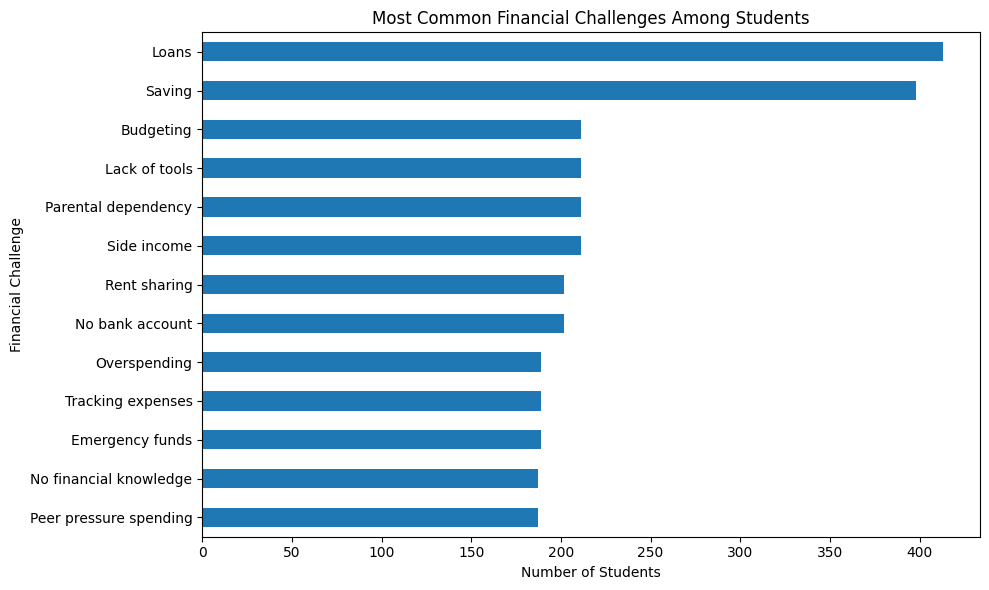

In [ ]:
plt.figure(figsize=(10, 6))

challenge_counts.sort_values().plot(kind='barh')

plt.title('Most Common Financial Challenges Among Students')
plt.xlabel('Number of Students')
plt.ylabel('Financial Challenge')

plt.tight_layout()
plt.show()

Financial Struggles Segment-wise

In [ ]:
challenge_df = (
    df[['Student_ID', 'Student_Segment', 'Top_3_Money_Challenges']]
    .assign(
        Challenge=lambda x:
        x['Top_3_Money_Challenges'].str.split(',')
    )
    .explode('Challenge')
)

challenge_df['Challenge'] = challenge_df['Challenge'].str.strip()

challenge_df.head()

,Student_ID,Student_Segment,Top_3_Money_Challenges,Challenge
0,1,Dependent but App-Savvy,"Peer pressure spending, No financial knowledge...",Peer pressure spending
0,1,Dependent but App-Savvy,"Peer pressure spending, No financial knowledge...",No financial knowledge
0,1,Dependent but App-Savvy,"Peer pressure spending, No financial knowledge...",Saving
1,2,Non-Digital Planners,"Loans, Rent sharing, No bank account",Loans
1,2,Non-Digital Planners,"Loans, Rent sharing, No bank account",Rent sharing


In [ ]:
segment_challenges = pd.crosstab(
    challenge_df['Challenge'],
    challenge_df['Student_Segment']
)

segment_challenges

Student_Segment,Dependent but App-Savvy,Financially Proactive,Non-Digital Planners
Challenge,,,
Budgeting,89,82,40
Emergency funds,88,73,28
Lack of tools,75,95,41
Loans,166,164,83
No bank account,77,82,43
No financial knowledge,74,82,31
Overspending,88,73,28
Parental dependency,75,95,41
Peer pressure spending,74,82,31


In [ ]:
# Number of students in each segment
segment_sizes = df['Student_Segment'].value_counts()

# Raw challenge counts by segment
segment_challenge_counts = pd.crosstab(
    challenge_df['Challenge'],
    challenge_df['Student_Segment']
)

# Percentage of students in each segment reporting each challenge
segment_challenge_pct = (
    segment_challenge_counts
    .div(segment_sizes, axis=1)
    * 100
).round(1)

segment_challenge_pct

Student_Segment,Dependent but App-Savvy,Financially Proactive,Non-Digital Planners
Challenge,,,
Budgeting,22.1,19.8,21.9
Emergency funds,21.8,17.6,15.3
Lack of tools,18.6,22.9,22.4
Loans,41.2,39.6,45.4
No bank account,19.1,19.8,23.5
No financial knowledge,18.4,19.8,16.9
Overspending,21.8,17.6,15.3
Parental dependency,18.6,22.9,22.4
Peer pressure spending,18.4,19.8,16.9


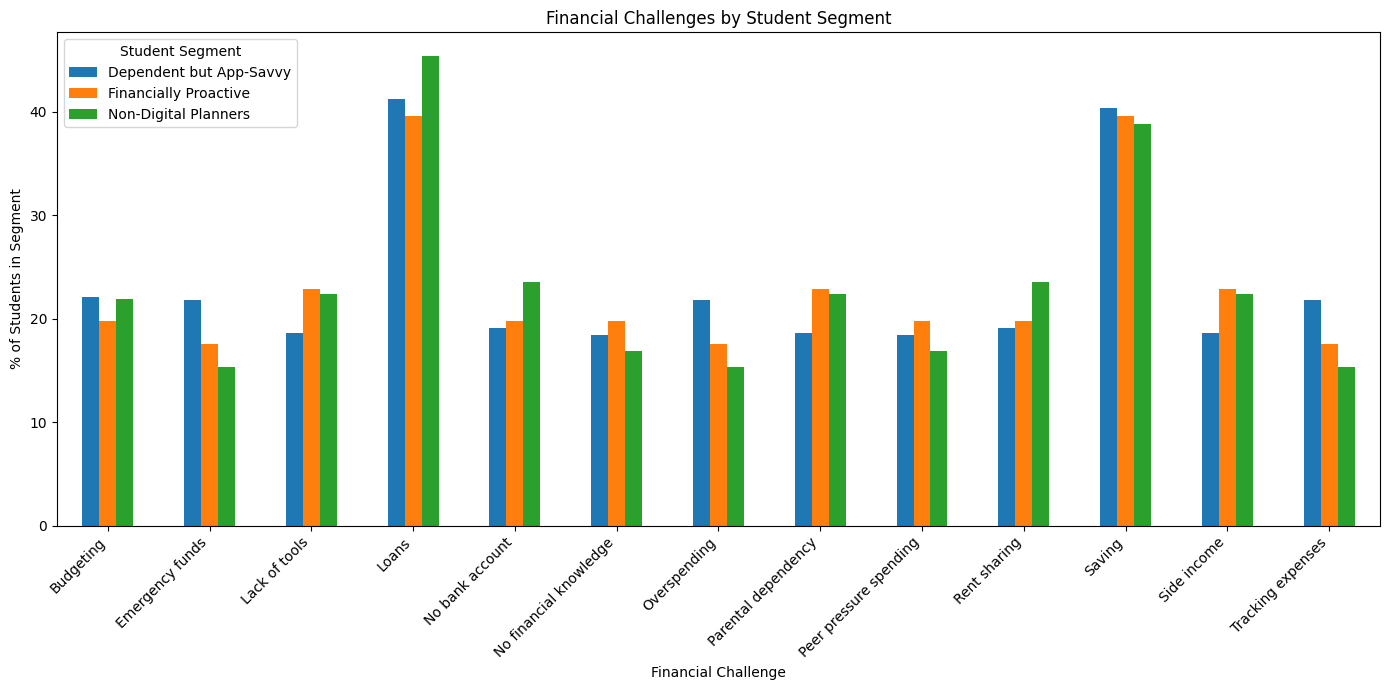

In [ ]:
segment_challenge_pct.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Financial Challenges by Student Segment')
plt.xlabel('Financial Challenge')
plt.ylabel('% of Students in Segment')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Student Segment')

plt.tight_layout()
plt.show()

Finance-app Adoption

In [ ]:
# Finance app usage distribution

app_usage = (
    df['Uses_Finance_App']
    .fillna('No Finance App')
    .value_counts()
)

app_usage

,count
Uses_Finance_App,
Splitwise,210
Walnut,209
Cred,202
Jupiter,196
No Finance App,183


In [ ]:
app_usage_pct = (
    df['Uses_Finance_App']
    .fillna('No Finance App')
    .value_counts(normalize=True)
    * 100
).round(1)

app_usage_pct

,proportion
Uses_Finance_App,
Splitwise,21.0
Walnut,20.9
Cred,20.2
Jupiter,19.6
No Finance App,18.3


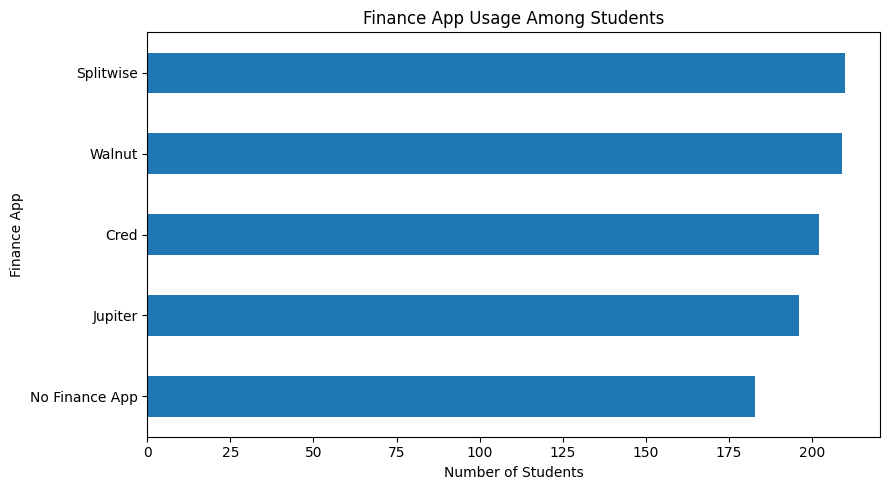

In [ ]:
plt.figure(figsize=(9, 5))

app_usage.sort_values().plot(kind='barh')

plt.title('Finance App Usage Among Students')
plt.xlabel('Number of Students')
plt.ylabel('Finance App')

plt.tight_layout()
plt.show()

In [ ]:
# Compare finance app adoption by college tier

app_by_tier = pd.crosstab(
    df['College_Tier'],
    df['Uses_Finance_App'].notna(),
    normalize='index'
) * 100

app_by_tier.columns = ['No Finance App', 'Uses Finance App']

app_by_tier.round(1)

,No Finance App,Uses Finance App
College_Tier,,
Tier 1,19.5,80.5
Tier 2,18.1,81.9
Tier 3,17.4,82.6


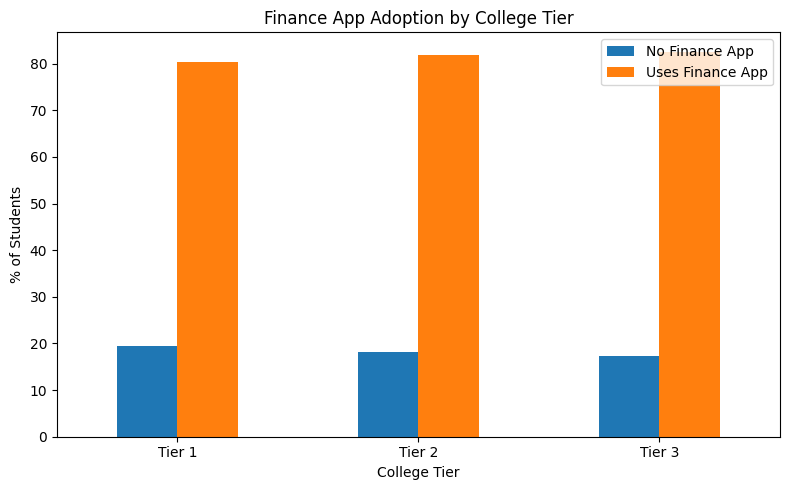

In [ ]:
app_by_tier.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Finance App Adoption by College Tier')
plt.xlabel('College Tier')
plt.ylabel('% of Students')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Finance app adoption by city type

app_by_city = pd.crosstab(
    df['City_Type'],
    df['Uses_Finance_App'].notna(),
    normalize='index'
) * 100

app_by_city.columns = ['No Finance App', 'Uses Finance App']

app_by_city.round(1)

,No Finance App,Uses Finance App
City_Type,,
Rural,15.7,84.3
Semi-urban,20.4,79.6
Urban,19.0,81.0


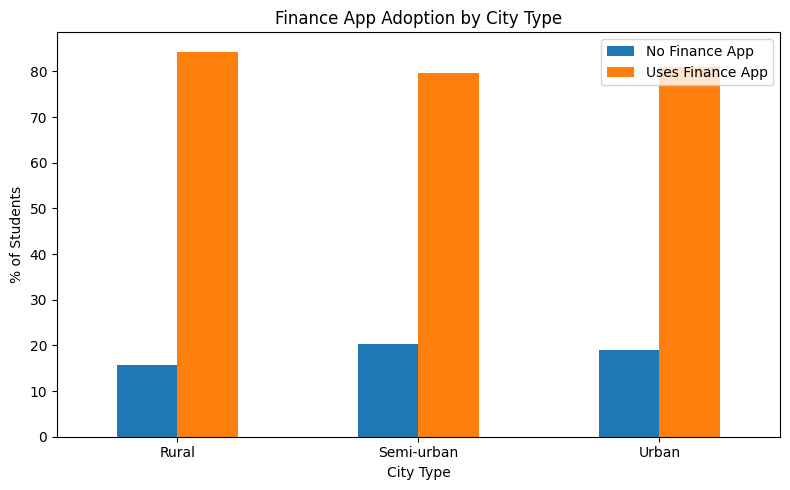

In [ ]:
app_by_city.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Finance App Adoption by City Type')
plt.xlabel('City Type')
plt.ylabel('% of Students')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
city_challenge_df = (
    df[['Student_ID', 'City_Type', 'Top_3_Money_Challenges']]
    .assign(
        Challenge=lambda x:
        x['Top_3_Money_Challenges'].str.split(',')
    )
    .explode('Challenge')
)

city_challenge_df['Challenge'] = (
    city_challenge_df['Challenge']
    .str.strip()
)

In [ ]:
city_challenge_counts = pd.crosstab(
    city_challenge_df['Challenge'],
    city_challenge_df['City_Type']
)

city_sizes = df['City_Type'].value_counts()

city_challenge_pct = (
    city_challenge_counts
    .div(city_sizes, axis=1)
    * 100
).round(1)

city_challenge_pct

City_Type,Rural,Semi-urban,Urban
Challenge,,,
Budgeting,20.9,20.9,21.5
Emergency funds,17.7,19.5,19.6
Lack of tools,22.3,18.9,22.2
Loans,40.6,43.1,40.2
No bank account,19.7,22.1,18.7
No financial knowledge,19.4,18.6,18.0
Overspending,17.7,19.5,19.6
Parental dependency,22.3,18.9,22.2
Peer pressure spending,19.4,18.6,18.0


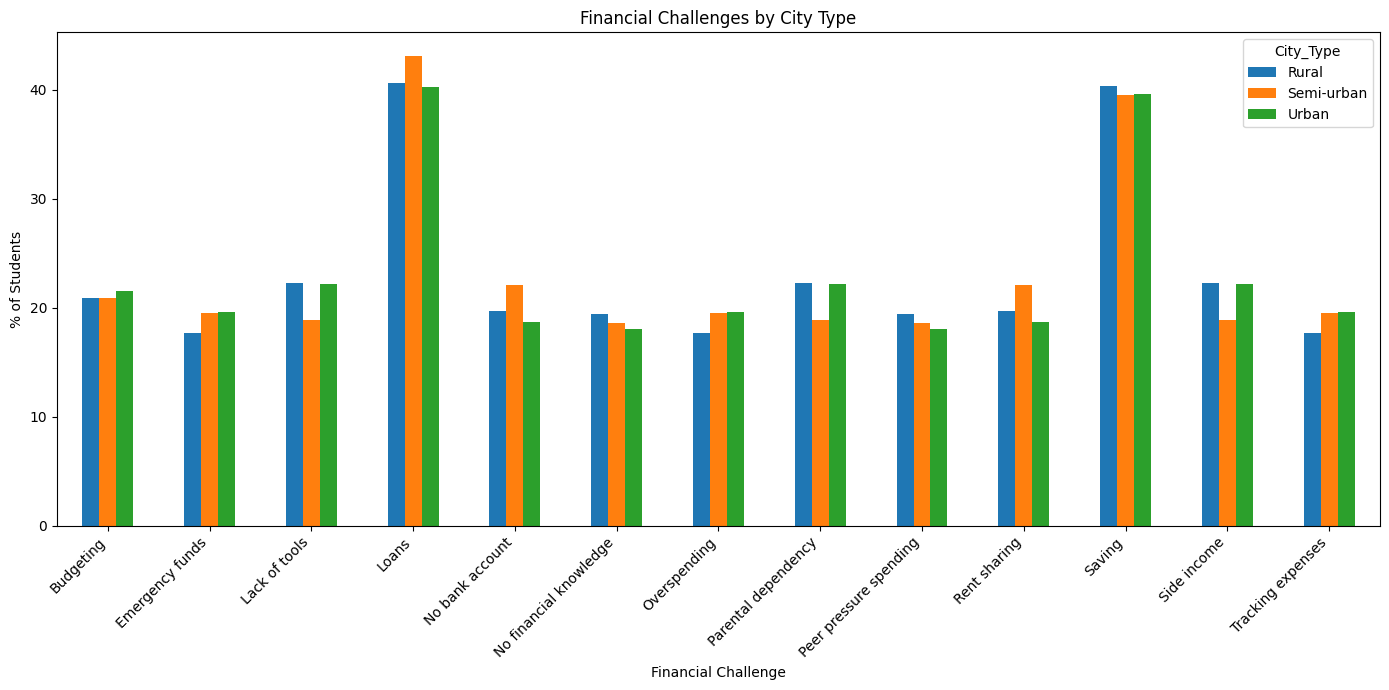

In [ ]:
city_challenge_pct.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Financial Challenges by City Type')
plt.xlabel('Financial Challenge')
plt.ylabel('% of Students')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# Average monthly allowance by city type

city_allowance = (
    df.groupby('City_Type')['Monthly_Allowance']
    .agg(['count', 'mean'])
    .round(0)
)

city_allowance

,count,mean
City_Type,,
Rural,345,5003.0
Semi-urban,339,4876.0
Urban,316,4870.0


In [ ]:
# Average allowance by part-time job status

job_allowance = (
    df.groupby('Has_Part_Time_Job')['Monthly_Allowance']
      .agg(['count', 'mean', 'median'])
      .round(0)
)

job_allowance

,count,mean,median
Has_Part_Time_Job,,,
No,495,4974.0,5000.0
Yes,505,4863.0,5000.0


In [ ]:
# Finance app adoption by part-time job status

job_app_usage = pd.crosstab(
    df['Has_Part_Time_Job'],
    df['Uses_Finance_App'].notna(),
    normalize='index'
) * 100

job_app_usage.columns = ['No Finance App', 'Uses Finance App']

job_app_usage.round(1)

,No Finance App,Uses Finance App
Has_Part_Time_Job,,
No,18.6,81.4
Yes,18.0,82.0


In [ ]:
job_challenge_df = (
    df[['Student_ID', 'Has_Part_Time_Job', 'Top_3_Money_Challenges']]
    .assign(
        Challenge=lambda x:
        x['Top_3_Money_Challenges'].str.split(',')
    )
    .explode('Challenge')
)

job_challenge_df['Challenge'] = (
    job_challenge_df['Challenge']
    .str.strip()
)

In [ ]:
# Challenge counts

job_challenge_counts = pd.crosstab(
    job_challenge_df['Challenge'],
    job_challenge_df['Has_Part_Time_Job']
)

job_sizes = df['Has_Part_Time_Job'].value_counts()

# % of students in each group reporting the challenge

job_challenge_pct = (
    job_challenge_counts
    .div(job_sizes, axis=1)
    * 100
).round(1)

job_challenge_pct

Has_Part_Time_Job,No,Yes
Challenge,,
Budgeting,22.4,19.8
Emergency funds,21.0,16.8
Lack of tools,18.8,23.4
Loans,42.0,40.6
No bank account,19.6,20.8
No financial knowledge,18.2,19.2
Overspending,21.0,16.8
Parental dependency,18.8,23.4
Peer pressure spending,18.2,19.2


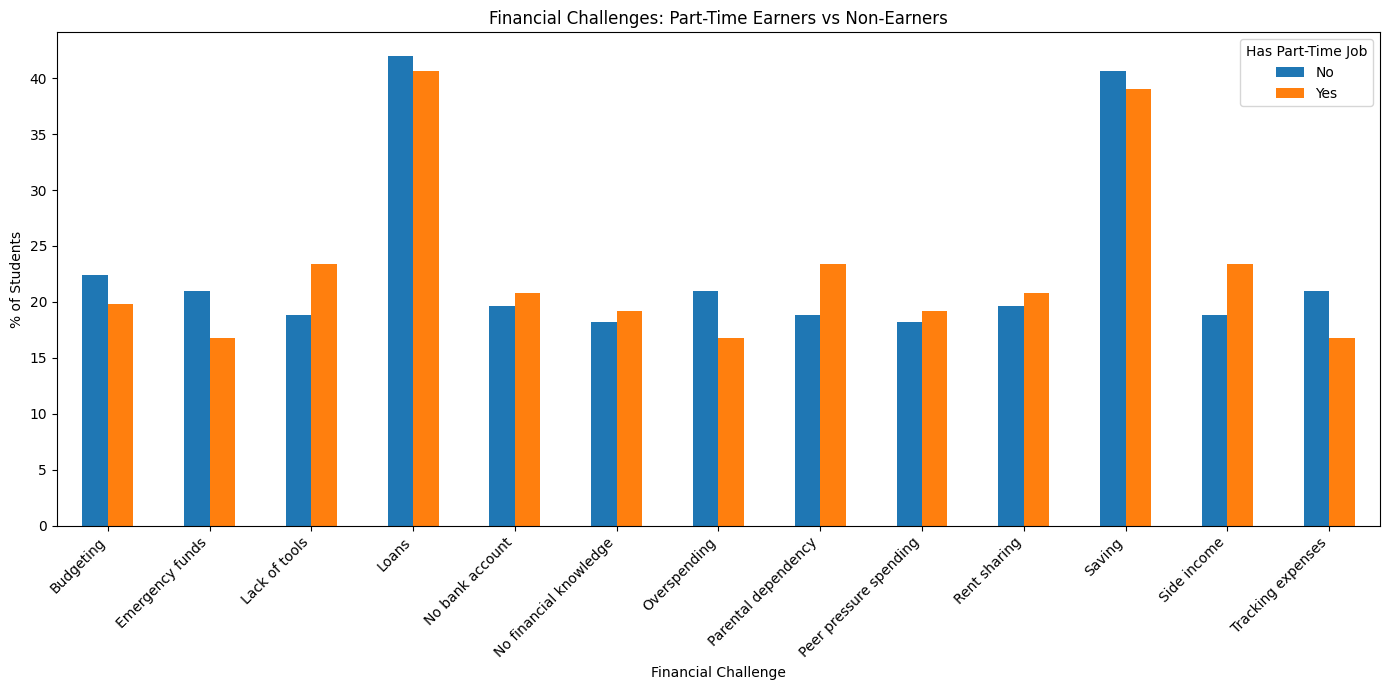

In [ ]:
job_challenge_pct.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Financial Challenges: Part-Time Earners vs Non-Earners')
plt.xlabel('Financial Challenge')
plt.ylabel('% of Students')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Has Part-Time Job')

plt.tight_layout()
plt.show()

In [ ]:
df['Monthly_Allowance'].value_counts().sort_index()

,count
Monthly_Allowance,
2000,163
3000,150
4000,134
5000,136
6000,136
7000,138
8000,143


In [ ]:
# Create allowance groups

def allowance_group(x):
    if x <= 3000:
        return 'Low (₹2K-₹3K)'
    elif x <= 5000:
        return 'Medium (₹4K-₹5K)'
    else:
        return 'High (₹6K-₹8K)'

df['Allowance_Group'] = df['Monthly_Allowance'].apply(allowance_group)

df['Allowance_Group'].value_counts()

,count
Allowance_Group,
High (₹6K-₹8K),417
Low (₹2K-₹3K),313
Medium (₹4K-₹5K),270


In [ ]:
allowance_challenge_df = (
    df[['Student_ID', 'Allowance_Group', 'Top_3_Money_Challenges']]
    .assign(
        Challenge=lambda x:
        x['Top_3_Money_Challenges'].str.split(',')
    )
    .explode('Challenge')
)

allowance_challenge_df['Challenge'] = (
    allowance_challenge_df['Challenge']
    .str.strip()
)

In [ ]:
# Count each challenge by allowance group

allowance_challenge_counts = pd.crosstab(
    allowance_challenge_df['Challenge'],
    allowance_challenge_df['Allowance_Group']
)

allowance_sizes = df['Allowance_Group'].value_counts()

allowance_challenge_pct = (
    allowance_challenge_counts
    .div(allowance_sizes, axis=1)
    * 100
).round(1)

allowance_challenge_pct

Allowance_Group,High (₹6K-₹8K),Low (₹2K-₹3K),Medium (₹4K-₹5K)
Challenge,,,
Budgeting,20.9,17.9,25.2
Emergency funds,15.8,22.4,19.6
Lack of tools,21.8,20.1,21.1
Loans,44.4,37.1,41.5
No bank account,23.5,19.2,16.3
No financial knowledge,18.0,20.4,17.8
Overspending,15.8,22.4,19.6
Parental dependency,21.8,20.1,21.1
Peer pressure spending,18.0,20.4,17.8


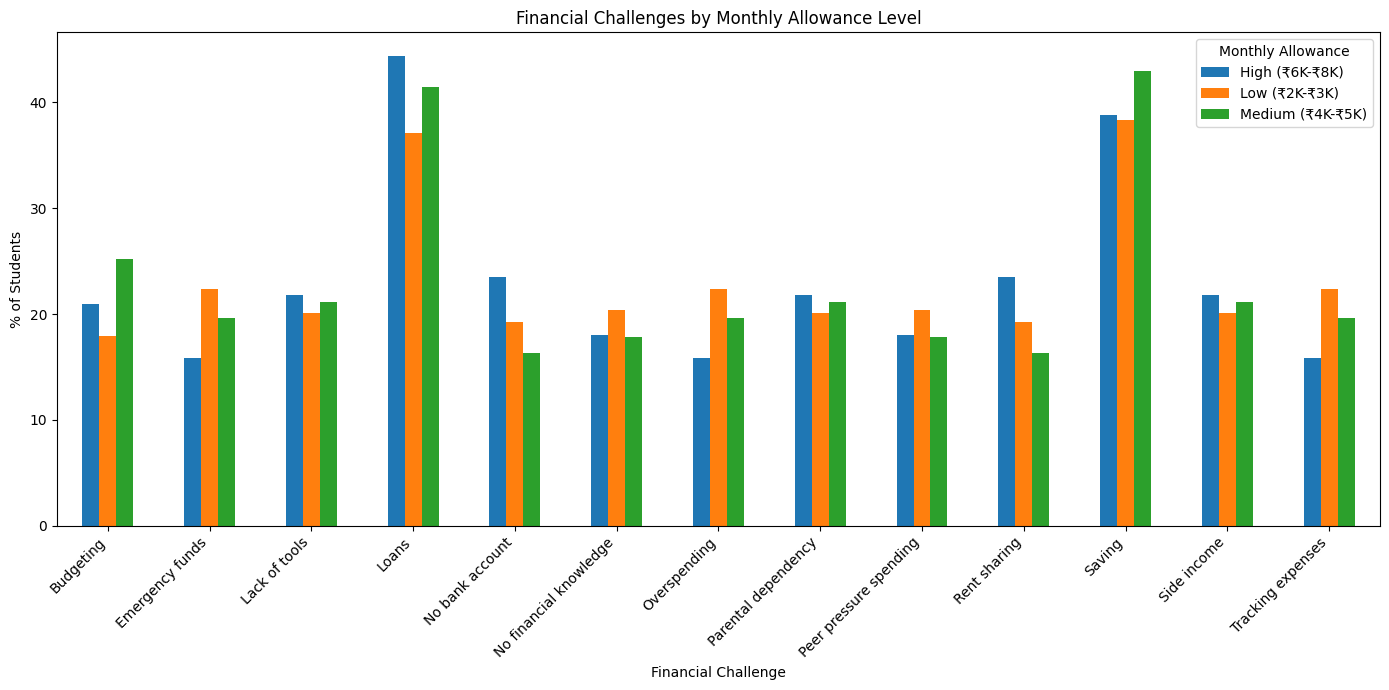

In [ ]:
allowance_challenge_pct.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Financial Challenges by Monthly Allowance Level')
plt.xlabel('Financial Challenge')
plt.ylabel('% of Students')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Monthly Allowance')

plt.tight_layout()
plt.show()

In [ ]:
app_by_allowance = pd.crosstab(
    df['Allowance_Group'],
    df['Uses_Finance_App'].notna(),
    normalize='index'
) * 100

app_by_allowance.columns = ['No Finance App', 'Uses Finance App']

app_by_allowance.round(1)

,No Finance App,Uses Finance App
Allowance_Group,,
High (₹6K-₹8K),21.3,78.7
Low (₹2K-₹3K),16.0,84.0
Medium (₹4K-₹5K),16.3,83.7
